# Laboratorio 1 — Series de Tiempo · 📓 Notebook 2 de 2
### Series por País de residencia — Ingreso de viajeros internacionales a Guatemala

**Curso:** CC3084 · Data Science · **Semestre II, 2026** · UVG

> **Prerrequisito:** revisar primero el **Notebook 1** (`Lab1_Series_Tiempo.ipynb`), que contiene el
> **análisis exploratorio general** (calidad de datos, pandemia, quiebres metodológicos, etc.). Este
> Notebook 2 reutiliza esa misma metodología aplicada a los **tres países de residencia** con mayor
> número acumulado de viajeros.

**Series de este notebook** (criterio: total acumulado de `Turista + Excursionista` en todo el período):
1. **El Salvador**
2. **Estados Unidos de América**
3. **Honduras**

> *Nota:* el top-3 literal incluía "Guatemala", pero corresponde a **residentes nacionales
> retornando** (no es un mercado extranjero) y su serie se corta en 2022 por el cambio de
> granularidad; por eso se excluye y se toma el siguiente país (Honduras). Justificación en el
> `README.md` y en el EDA del Notebook 1.

## 0. Configuración y funciones de análisis

Este notebook es **autocontenido**: define las mismas funciones auxiliares del Notebook 1
(`resumen_serie`, `comparar_descomposicion`, `media_std_movil`, `prueba_adf`, `prueba_kpss`,
`acf_pacf`) para que puedas aplicarlas directamente a las series de países.

In [1]:
# !pip install numpy pandas matplotlib seaborn statsmodels scikit-learn openpyxl
# Para el modelado (secciones TODO):
# !pip install pmdarima prophet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Entorno listo.")

Entorno listo.


In [3]:
# ---- Funciones auxiliares (idénticas a las del Notebook 1) ----
def resumen_serie(s):
    return pd.Series({
        "Inicio": s.index.min().strftime("%Y-%m"),
        "Fin": s.index.max().strftime("%Y-%m"),
        "Frecuencia": s.index.freqstr,
        "N observaciones": len(s),
        "Media": s.mean(), "Mínimo": s.min(), "Máximo": s.max(),
    })

def comparar_descomposicion(s, titulo):
    desc_add = seasonal_decompose(s, model="additive", period=12)
    desc_mul = seasonal_decompose(s, model="multiplicative", period=12)
    fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
    for j, (desc, nombre) in enumerate([(desc_add, "Aditiva"), (desc_mul, "Multiplicativa")]):
        axes[0, j].plot(s, color="#333"); axes[0, j].set_title(f"{titulo} — {nombre}")
        axes[1, j].plot(desc.trend, color="#1f77b4"); axes[1, j].set_ylabel("tendencia")
        axes[2, j].plot(desc.seasonal, color="#2ca02c"); axes[2, j].set_ylabel("estacional")
        axes[3, j].plot(desc.resid, color="#d62728", marker=".", ls="none", ms=3)
        axes[3, j].set_ylabel("residuo")
    plt.tight_layout(); plt.show()
    return desc_add, desc_mul

def media_std_movil(s, titulo, ventana=12):
    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(s, color="#bbb", label="serie")
    ax[0].plot(s.rolling(ventana).mean(), color="#1f77b4", label=f"media móvil ({ventana}m)")
    ax[0].set_title(f"{titulo} — media móvil"); ax[0].legend()
    ax[1].plot(s.rolling(ventana).std(), color="#d62728", label=f"std móvil ({ventana}m)")
    ax[1].set_title("Desviación estándar móvil"); ax[1].legend()
    plt.tight_layout(); plt.show()

def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "ESTACIONARIA" if r[1] < 0.05 else "NO estacionaria"
    print(f"ADF  {nombre:32s} estad={r[0]:7.3f}  p-valor={r[1]:.4f}  -> {veredicto}")
    return r[1]

def prueba_kpss(x, nombre=""):
    stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
    veredicto = "NO estacionaria" if p < 0.05 else "ESTACIONARIA"
    print(f"KPSS {nombre:32s} estad={stat:7.3f}  p-valor={p:.4f}  -> {veredicto}")
    return p

def acf_pacf(s, titulo, lags=36):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s.dropna(), lags=lags, ax=ax[0]); ax[0].set_title(f"ACF — {titulo}")
    plot_pacf(s.dropna(), lags=lags, ax=ax[1], method="ywm"); ax[1].set_title(f"PACF — {titulo}")
    plt.tight_layout(); plt.show()

print("Funciones auxiliares cargadas.")

Funciones auxiliares cargadas.


## 1. Carga de datos y construcción de las tres series

Mismo filtro consistente que en el Notebook 1: `Turista + Excursionista`, agregación mensual (`MS`).

In [4]:
ARCHIVO = "Base_Migracion_2009-2026jun.xlsx"
df = pd.read_excel(ARCHIVO, sheet_name="Datos")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))
base = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]

PAISES = ["El Salvador", "Estados Unidos de América", "Honduras"]
rango = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="MS")

series_pais = {}
for p in PAISES:
    s = base[base["País"] == p].groupby("Fecha")["Viajero"].sum().reindex(rango)
    series_pais[p] = s

# Diagnóstico de meses faltantes (deben ser abr-ago 2020: cierre por pandemia)
for p, s in series_pais.items():
    faltan = [d.strftime("%Y-%m") for d in s[s.isna()].index]
    print(f"{p:28s} -> meses sin registro: {faltan}")

El Salvador                  -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']
Estados Unidos de América    -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']
Honduras                     -> meses sin registro: ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']


### 1.1 Tratamiento de los meses del cierre pandémico (abr–ago 2020)

Los únicos meses faltantes son **abril a agosto de 2020**, cuando las fronteras y el aeropuerto
estuvieron cerrados: no hubo arribos registrados. Los rellenamos con **0** (refleja el cierre real).

> ⚠️ **Para el modelado con `log`:** `log(0)` no existe. Cuando transformes la varianza, usa
> `np.log1p` (equivale a `log(1+x)`) o suma una constante pequeña. Estos 5 ceros son el mismo
> **quiebre estructural de la pandemia** discutido en el Notebook 1: tenlo presente al descomponer y
> modelar (considera tratarlos como valores atípicos/intervención si el modelo lo requiere).

In [5]:
for p in PAISES:
    series_pais[p] = series_pais[p].fillna(0.0).asfreq("MS")
    series_pais[p].name = p

serie_sv  = series_pais["El Salvador"]
serie_usa = series_pais["Estados Unidos de América"]
serie_hn  = series_pais["Honduras"]

print("Longitudes (deben ser 210, sin NaN):")
for p, s in series_pais.items():
    print(f"  {p:28s} n={len(s)}  NaN={s.isna().sum()}")

Longitudes (deben ser 210, sin NaN):
  El Salvador                  n=210  NaN=0
  Estados Unidos de América    n=210  NaN=0
  Honduras                     n=210  NaN=0


## 2. Inicio, fin y frecuencia *(Requisito 4a)*

In [6]:
pd.DataFrame({p: resumen_serie(s) for p, s in series_pais.items()})

,El Salvador,Estados Unidos de América,Honduras
Inicio,2009-01,2009-01,2009-01
Fin,2026-06,2026-06,2026-06
Frecuencia,MS,MS,MS
N observaciones,210,210,210
Media,"67,043.50","33,169.90","12,004.64"
Mínimo,0.00,0.00,0.00
Máximo,"190,578.96","78,927.16","35,252.51"


## 3. Gráfico de las series *(Requisito 4b)*

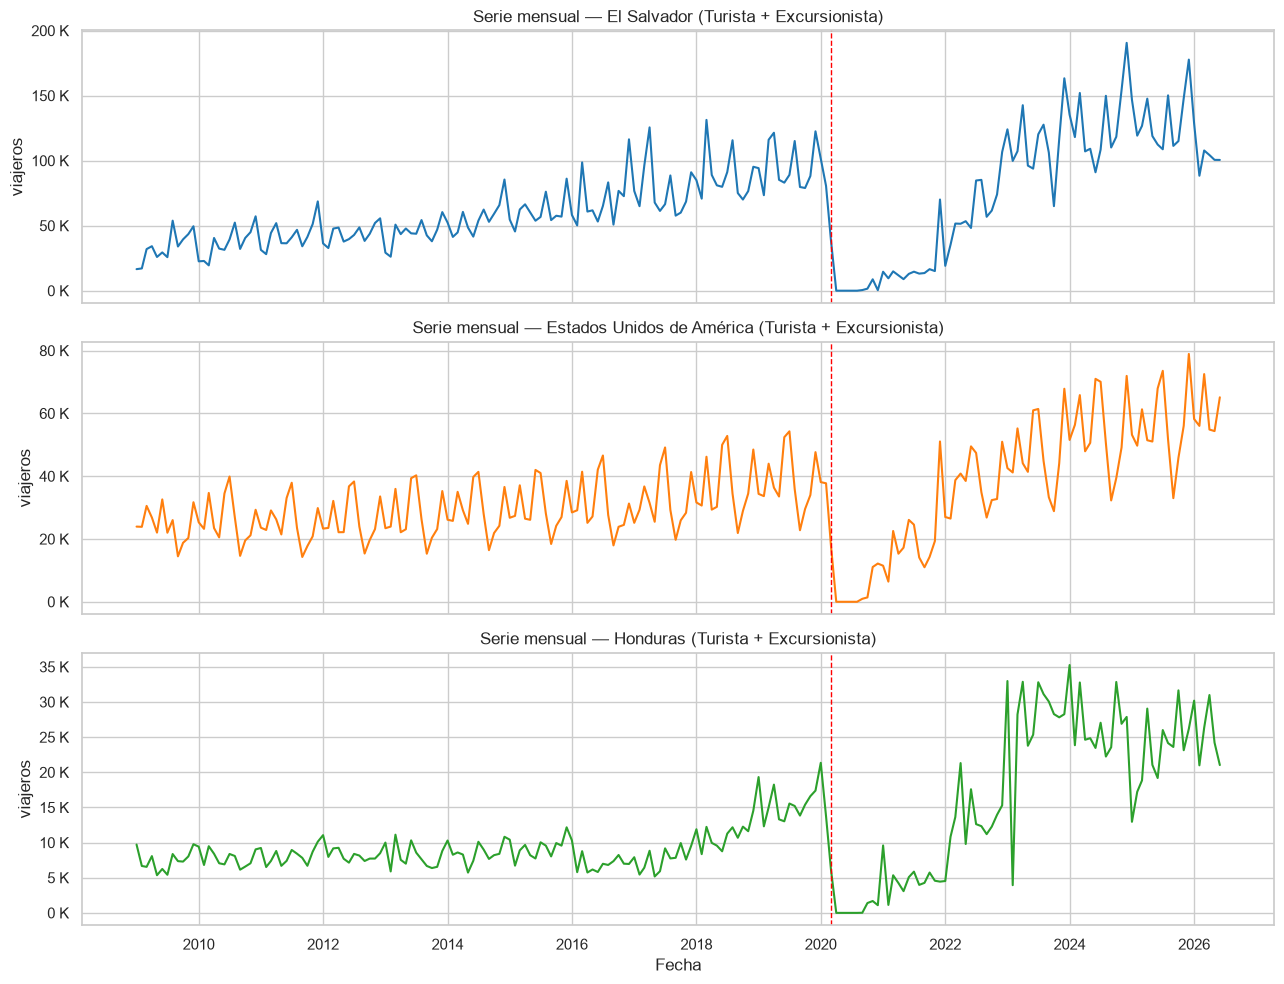

In [7]:
colores = {"El Salvador": "#1f77b4", "Estados Unidos de América": "#ff7f0e", "Honduras": "#2ca02c"}
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, (p, s) in zip(axes, series_pais.items()):
    ax.plot(s.index, s.values, color=colores[p])
    ax.axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1)
    ax.set_title(f"Serie mensual — {p} (Turista + Excursionista)")
    ax.set_ylabel("viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
axes[-1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()